# NGC 4151 GTI fit using the full-observation light-curve catalog


This notebook follows `NGC4151_DC4_Spectral_Fit_Source_Cat_fit_norm_all.ipynb`,
but uses the **full-observation light-curve catalog and companion response JSON**.
It keeps all 71 entries (52 point sources and 19 extended sources) in the model.
Only NGC 4151's CPL normalization, index, and cutoff energy, plus the instrumental
background rate, are free. Its pivot is fixed at 200 keV. The injected reference
curve remains CPL + PL, so a CPL-only fit need not reproduce its high-energy tail.

The YAML already contains each component's full-observation temporal-mean normalization.
The point-source response is weighted by `L(t) / mean_full(L)` **over the NGC 4151 GTI only**; do not apply another
duration factor. The JSON selects the same parallel-chunk settings used by the
generator. Crab's four component responses are summed **inside one catalog source**.
Steady extended components retain the cached ordinary GTI extended response.

The notebook verifies light-curve hashes and full-observation temporal factors, and uses the NGC 4151 GTI for data and responses. It checks
response paths before fitting. The nova's 500-chunk setting remains an inferred
simulation assumption, and the catalog retains the generator's known count
discrepancies. It does not refit nuisance-source normalizations to FITS counts.

Existing catalogs, source events and response files are read-only inputs. No
catalog or background file is rewritten. Run from the top in a fresh kernel;
the extended response alone requires about 13 GiB of memory. The helper files
`dc4_temporal_fit.py` and `dc4_lightcurve_response.py` must remain beside this notebook.

Both fits use the same full mock dataset containing all sources, with the NGC 4151 GTI applied.
A baseline fit uses **NGC 4151 alone plus the same instrumental background**, with
the same data, GTI, CPL starting parameters and bounds. The other sources remain
in the observed data but are omitted from this comparison model. Both fits are
overlaid on the spectral plot. This is a test of omitted-source bias, not a fit
to an isolated-source simulated dataset. Each fit has its own model, response,
background-rate parameter and uncertainty results.
If threeML reports parameters at bounds or substantial rejection of covariance
samples, the corresponding plotted 68% band is not a reliable confidence region;
inspect the fit constraints before interpreting it.


In [1]:
from pathlib import Path
from copy import deepcopy
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from astromodels import (
    Cutoff_powerlaw, ExtendedSource, PointSource, Parameter, Powerlaw, Model, load_model,
)
from histpy import Histogram
from threeML import DataList, JointLikelihood

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
    BinnedThreeMLExtendedSourceResponse,
    ExtendedSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood
from cosipy.threeml.custom_functions import GalpropHealpixModel, SpecFromDat  # noqa: F401

%matplotlib inline

23:04:25 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=297612;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=117004;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=871594;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=130177;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=646110;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=512196;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

23:04:26 INFO      Starting 3ML!                                                                     ]8;id=185871;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=731214;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=118292;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=916169;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=705937;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=145912;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

23:04:27 WARNING   No fermitools installed                                              ]8;id=69328;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=811326;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=535515;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=736510;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=363554;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=817576;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=772055;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=362696;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Load the FOV-cut data and response

The mock-data and background files below were binned after applying the same 60° NGC 4151 pointing cut used for the spacecraft history.

In [2]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN"
)
dc4_root_candidates = [
    Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files"),
    Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files"),
]
dc4_files_root = next((p for p in dc4_root_candidates if p.exists()), None)
if dc4_files_root is None:
    raise FileNotFoundError(f"Cannot find DC4 data: {dc4_root_candidates}")

# Keep the existing updated-NGC4151 mock dataset and instrumental background.
mock_data_path = dc4_files_root / (
    "Mock_Data/Mock_Data_Cut/mock_with_updated_NGC4151_FluxNTH_0p30_time_cut.hdf5"
)
background_path = dc4_files_root / (
    "Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "NGC4151_60deg_fov_cut.hdf5"
)
orientation_path = dc4_files_root / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
response_path = dc4_files_root / (
    "ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
agn_config = notebook_dir / "agn.yaml"
source_catalog_path = notebook_dir / "source_catalog_DC4_all_71files_full_elapsed_lightcurve_response_norm.yaml"
response_recipe_path = source_catalog_path.with_suffix(".response.json")

if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))
from dc4_temporal_fit import load_recipe, make_temporal_responses

extended_response_path = dc4_files_root / (
    "Extended_Responses/NGC4151_Cut/"
    "DC4_continuum_NGC4151_60deg_GTI_extended_response_nside8.h5"
)

# Scale counts and both response exposures, never the catalog flux parameters.
# Eight repetitions represent 24 months; they are not a new Poisson realization.
exposure_multiplier = 1
exposure_months = 3 * exposure_multiplier
if not np.isfinite(exposure_multiplier) or exposure_multiplier <= 0:
    raise ValueError("exposure_multiplier must be finite and positive")

for path in (mock_data_path, background_path, orientation_path, response_path,
             agn_config, source_catalog_path, response_recipe_path, extended_response_path):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing input: {path}. Generate the full catalog and GTI extended "
            "response with Source_catalog_generator_all_DC4_lightcurve.ipynb first."
        )

model = load_model(source_catalog_path)
if len(model.sources) != 71 or "ngc4151" not in model.point_sources:
    raise RuntimeError("Expected the complete 71-entry catalog including ngc4151")
if model.free_parameters:
    raise RuntimeError("The input catalog must have all parameters fixed")
print("Catalog:", source_catalog_path.name)
print(f"Sources: {len(model.point_sources)} point + {len(model.extended_sources)} extended")
print("Extended response:", extended_response_path)
recipe = load_recipe(response_recipe_path, source_catalog_path, model)
if recipe["selection"] != "full":
    raise ValueError("This notebook uses full-observation catalog normalizations")
for name, expected_path in (("orientation", orientation_path),
                            ("detector_response", response_path), ("binning", agn_config)):
    if Path(recipe[name]).resolve() != expected_path.resolve():
        raise ValueError(f"{name} does not match the catalog response recipe")
print("Temporal response recipe:", response_recipe_path.name)
print("Normalization assumptions:", recipe["normalization_assumptions"])


Catalog: source_catalog_DC4_all_71files_full_elapsed_lightcurve_response_norm.yaml
Sources: 52 point + 19 extended
Extended response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Extended_Responses/NGC4151_Cut/DC4_continuum_NGC4151_60deg_GTI_extended_response_nside8.h5
Temporal response recipe: source_catalog_DC4_all_71files_full_elapsed_lightcurve_response_norm.response.json
Normalization assumptions: Mission-grid profiles: 1000 parallel chunks; nova continuum: inferred 500 chunks. Verify against archived run configurations.


The analysis still uses the existing NGC 4151 60-degree pointing/occultation
cut, matching the mock data, instrumental background, and cached extended response.
The full catalog's `gti_target` JSON field describes its generator's other GTI
output; it does **not** select the analysis intervals for the full catalog.

Keep both the original full history (to verify the full normalization) and the
unscaled GTI history (to construct the analysis responses). Variable response
weights are `L(t) / mean_full(L)`, not `L(t) / mean_GTI(L)`. The YAML remains
unchanged. Exposure multiplication repeats the GTI history and its transients;
it does not generate an independent 24-month realization.


In [3]:
source_l = model.ngc4151.position.l.value * u.deg
source_b = model.ngc4151.position.b.value * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

# These settings belong to the selected data, not to the full catalog.
max_offaxis = 60.0 * u.deg
earth_occ = True

sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

# Repeat the selected pointing history by scaling its interval livetimes.
# The attitude and Earth-occultation selection remain unchanged.
sc_orientation = SpacecraftHistory(
    sc_orientation_cut.obstime,
    sc_orientation_cut.attitude,
    sc_orientation_cut.location,
    livetime=sc_orientation_cut.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_cut.cache_earth_occ


full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
fov_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
scaled_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Three-month GTI livetime: {fov_livetime:,.1f} s")
print(f"Scaled {exposure_months}-month livetime: {scaled_livetime:,.1f} s")

Full orientation livetime: 6,579,555.0 s
Three-month GTI livetime: 980,415.0 s
Scaled 3-month livetime: 980,415.0 s


Load the same updated mock dataset and instrumental-background template as
the reference notebook. The mock already includes the other sources: do not
add them again. The background contains instrumental/background events, not the
catalog predictions. Preserve the reference notebook's machine-tiny numerical
floor and free background-rate parameter; light curves do not modify either.


In [4]:
mock_data = BinnedData(agn_config)
mock_data.load_binned_data_from_hdf5(binned_data=mock_data_path)

data_hist = mock_data.binned_data.project("Em", "Phi", "PsiChi")
data_hist *= exposure_multiplier

total_bkg = Histogram.open(background_path).project("Em", "Phi", "PsiChi")
if total_bkg.axes != data_hist.axes:
    raise ValueError("Mock data and background must have identical Em/Phi/PsiChi axes")
total_bkg *= exposure_multiplier
total_bkg += sys.float_info.min
bkg_dist = {"total_bkg": total_bkg}
# FreeNormBinnedBackground takes a rate in Hz, not a dimensionless multiplier.
background_rate_initial = float(total_bkg.to_dense(copy=False).contents.sum()) / scaled_livetime
if not np.isfinite(background_rate_initial) or background_rate_initial <= 0:
    raise ValueError("Invalid initial instrumental-background rate")
print(f"Initial instrumental-background rate: {background_rate_initial:.6g} Hz")

Initial instrumental-background rate: 25.5719 Hz


Open the continuum response.

In [5]:
dr = FullDetectorResponse.open(str(response_path))

## Perform the spectral fit

Construct the ordinary point and extended responses, then override variable
point sources with the matching temporal responses. `make_temporal_responses`
reads the actual normalization mode, chunk count and applied factor from the
JSON; it does not guess them or fit them again. It verifies the full-observation
duration and normalization factors, then restricts response exposure to the analysis GTI before applying exposure repetition.

The adapters retain the original 71-source astromodels catalog, including Crab's
component parameter paths. Sources with zero temporal exposure receive exact
zero predictions, even if their full-observation YAML amplitudes are nonzero.
No 13-GiB extended response is generated per point source. The ordinary extended
cube is loaded once and scaled only in memory. Temporal point responses are
computed lazily and reused during fitting.

Use the same unpolarized folding approximation as the generator. Polarization
metadata in the input YAML remain unchanged.


In [6]:
# Match the generator's unpolarized response approximation.
unpolarized_components = []
for source in model.sources.values():
    for component in source.components.values():
        degree = getattr(component.polarization, "degree", None)
        if degree is not None and degree.value != 0.0:
            degree.value = 0.0
            unpolarized_components.append(f"{source.name}.{component.name}")
print("Using unpolarized folding for:", unpolarized_components)

data = EmCDSBinnedData(data_hist)
bkg = FreeNormBinnedBackground(bkg_dist, sc_history=sc_orientation, copy=False)
instrument_response = BinnedInstrumentResponse(dr, data)
psr = BinnedThreeMLPointSourceResponse(
    data=data,
    instrument_response=instrument_response,
    sc_history=sc_orientation,
    energy_axis=dr.axes["Ei"],
    polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
    nside=2 * data.axes["PsiChi"].nside,
)

# Drop references to the previous response if this setup cell is rerun.
for name in ("like", "plugins", "cosi", "like_fun", "response", "esr", "extended_response", "source_specific_responses"):
    globals().pop(name, None)
print("Loading cached GTI extended response (about 13 GiB)...")
extended_response = ExtendedSourceResponse.open(extended_response_path)
if extended_response.axes["NuLambda"].nside != 8:
    raise ValueError("Expected the catalog generator's NSIDE-8 extended response")
if extended_response.axes[2:] != data.axes:
    raise ValueError("Extended response and data Em/Phi/PsiChi axes do not match")
if extended_response.axes["Ei"] != dr.axes["Ei"]:
    raise ValueError("Point and extended responses have different incident-energy bins")
extended_response *= exposure_multiplier
esr = BinnedThreeMLExtendedSourceResponse(
    data=data,
    precomputed_psr=extended_response,
)
source_specific_responses, temporal_diagnostics = make_temporal_responses(
    model, recipe, sc_orientation_cut, source_gti, data,
    instrument_response, dr, exposure_multiplier=exposure_multiplier,
    full_history=sc_orientation_full,
)
display(pd.DataFrame(temporal_diagnostics))
response = BinnedThreeMLModelFolding(
    data=data,
    point_source_response=psr,
    extended_source_response=esr,
    source_specific_point_source_responses=source_specific_responses,
)
like_fun = PoissonLikelihood(data, response, bkg)
cosi = ThreeMLPluginInterface("cosi", like_fun, response, bkg)
cosi.bkg_parameter["total_bkg"] = Parameter(
    "total_bkg",
    background_rate_initial,
    min_value=0.0,
    max_value=50.0,
    delta=max(0.05 * background_rate_initial, 1e-6),
    unit=u.Hz,
)
print(f"Mixed response ready for all {len(model.sources)} catalog sources.")
print("Temporal point-source overrides:", sorted(source_specific_responses))
print("Full-observation amplitudes are unchanged; responses integrate only over the NGC 4151 GTI.")
print("Response denominator = catalog full-observation mean, not the GTI mean.")


Using unpolarized folding for: ['crab.nebula', 'crab.peak1', 'crab.bridge', 'crab.peak2', 'grb_bn090424592.bn090424592', 'grb_bn100612726.bn100612726', 'grb_bn110605183.bn110605183', 'grb_bn131122490.bn131122490', 'grb_bn140329295.bn140329295', 'grb_bn161004964.bn161004964', 'grb_bn170405777.bn170405777', 'grb_bn180504136.bn180504136', 'grb_bn180703876.bn180703876', 'grb_bn080802386_flux150.bn080802386', 'mgf_051103.mgf051103', 'mgf_070201.mgf070201', 'mgf_070222.mgf070222', 'mgf_180128a.mgf180128a', 'mgf_200415a.mgf200415a', 'mgf_231115a.mgf231115a']
Loading cached GTI extended response (about 13 GiB)...


,source,component,normalization mode,simulation bins,catalog selection,catalog time factor,analysis GTI time factor,response denominator,weighted response seconds
0,crab,Crab_Nebula,steady,1,full,1.000000e+00,1.000000e+00,1.000000e+00,9.804150e+05
1,crab,Crab_P1,global_megalib,1,full,1.000000e+00,1.000000e+00,1.000000e+00,9.804151e+05
2,crab,Crab_Brg,global_megalib,1,full,1.000000e+00,1.000000e+00,1.000000e+00,9.804148e+05
3,crab,Crab_P2,global_megalib,1,full,1.000000e+00,1.000000e+00,1.000000e+00,9.804149e+05
4,four_c_21p35_noflare,all,parallel_megalib,1000,full,7.734254e-01,7.774102e-01,7.734254e-01,9.830386e+05
5,four_c_21p35_flare,all,parallel_megalib,1000,full,2.934490e-01,2.903921e-01,2.934490e-01,9.685894e+05
6,maxi_j1820,all,parallel_megalib,1000,full,6.497800e-01,6.479613e-01,6.497800e-01,9.778464e+05
7,maxi_j1348,all,parallel_megalib,1000,full,7.585757e-02,7.511794e-02,7.585757e-02,9.754807e+05
8,three_c_454p3_low,all,parallel_megalib,1000,full,6.506559e-01,6.503173e-01,6.506559e-01,9.789924e+05
9,three_c_454p3_high,all,parallel_megalib,1000,full,3.513403e-01,3.534195e-01,3.513403e-01,9.865371e+05


Mixed response ready for all 71 catalog sources.
Temporal point-source overrides: ['co_nova_478kev', 'co_nova_511kev', 'co_nova_continuum', 'crab', 'four_c_21p35_flare', 'four_c_21p35_noflare', 'generic_magnetar', 'grb_bn080802386_flux150', 'grb_bn081207680', 'grb_bn090424592', 'grb_bn100612726', 'grb_bn110605183', 'grb_bn131122490', 'grb_bn140329295', 'grb_bn161004964', 'grb_bn170405777', 'grb_bn180504136', 'grb_bn180703876', 'ls_5039', 'maxi_j1348', 'maxi_j1820', 'mgf_051103', 'mgf_070201', 'mgf_070222', 'mgf_180128a', 'mgf_200415a', 'mgf_231115a', 'mgt_burst_bright_complex', 'one_rxs_j170849', 'psr_b1259', 'psr_j1846', 'three_c_454p3_high', 'three_c_454p3_low']
Full-observation amplitudes are unchanged; responses integrate only over the NGC 4151 GTI.
Response denominator = catalog full-observation mean, not the GTI mean.


Replace only NGC 4151's in-memory catalog spectrum with a cutoff power
law. Fit its normalization `K`, photon index `index`, and cutoff energy `xc`.
The pivot remains fixed at 200 keV: freeing it together with `K` would create
a redundant normalization parameter. The source position and all 70 nuisance
sources remain fixed, and the YAML is not overwritten.

The injected reference remains the original CPL + PL used to generate the
mock data. Thus the comparison plot shows a **CPL-only fit** against the
**injected total (CPL + PL)**, not a changed simulation.

In [7]:
D = 0.30

# Injected spectrum used only for comparison in the plot.
spectrum_inj_cpl = Cutoff_powerlaw()
spectrum_inj_cpl.K.value = 0.15
spectrum_inj_cpl.piv.value = 1.0
spectrum_inj_cpl.xc.value = 200.0
spectrum_inj_cpl.index.value = -1.75
spectrum_inj_cpl.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_cpl.piv.unit = u.keV
spectrum_inj_cpl.xc.unit = u.keV

spectrum_inj_tail = Powerlaw()
spectrum_inj_tail.K.value = (
    D * spectrum_inj_cpl.evaluate_at(200.0)
)
spectrum_inj_tail.piv.value = 200.0
spectrum_inj_tail.index.value = -3.8
spectrum_inj_tail.K.unit = 1 / (u.cm**2 * u.s * u.keV)
spectrum_inj_tail.piv.unit = u.keV
spectrum_inj = spectrum_inj_cpl + spectrum_inj_tail

# Replace NGC 4151 only; initialize from the catalog's thermal component.
assert len(model.free_parameters) == 0
catalog_source = model.ngc4151
catalog_shape = catalog_source.spectrum.main.composite
spectrum_cpl = Cutoff_powerlaw(
    K=catalog_shape.K_1.value,
    piv=catalog_shape.piv_1.value,
    index=catalog_shape.index_1.value,
    xc=catalog_shape.xc_1.value,
)
ngc4151_cpl_source = PointSource(
    "ngc4151",
    l=catalog_source.position.l.value,
    b=catalog_source.position.b.value,
    spectral_shape=spectrum_cpl,
)
for parameter in ngc4151_cpl_source.parameters.values():
    parameter.fix = True
model.remove_source("ngc4151")
model.add_source(ngc4151_cpl_source)
ngc4151_fit = model.ngc4151.spectrum.main.Cutoff_powerlaw

ngc4151_fit.K.min_value = 1e-8
ngc4151_fit.K.max_value = 1e-2
ngc4151_fit.K.delta = 0.1 * ngc4151_fit.K.value
ngc4151_fit.K.fix = False

ngc4151_fit.index.min_value = -10.0
ngc4151_fit.index.max_value = 10.0
ngc4151_fit.index.delta = 0.1
ngc4151_fit.index.fix = False

ngc4151_fit.xc.min_value = 100.0
ngc4151_fit.xc.max_value = 10000.0
ngc4151_fit.xc.delta = 0.1 * ngc4151_fit.xc.value
ngc4151_fit.xc.fix = False
ngc4151_fit.piv.fix = True

expected_free_parameters = {
    "ngc4151.spectrum.main.Cutoff_powerlaw.K",
    "ngc4151.spectrum.main.Cutoff_powerlaw.index",
    "ngc4151.spectrum.main.Cutoff_powerlaw.xc",
}
assert set(model.free_parameters) == expected_free_parameters
assert len(model.sources) == 71
print("NGC 4151 fit model: cutoff power law only")
print("Free parameters:", list(model.free_parameters))
# Capture the identical starting point before either fit modifies parameters.
ngc4151_initial_source = deepcopy(model.ngc4151)


NGC 4151 fit model: cutoff power law only
Free parameters: ['ngc4151.spectrum.main.Cutoff_powerlaw.K', 'ngc4151.spectrum.main.Cutoff_powerlaw.index', 'ngc4151.spectrum.main.Cutoff_powerlaw.xc']


23:04:55 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=132048;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=846335;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=279631;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=409214;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

Fit the CPL source model and instrumental-background normalization once.
The first likelihood evaluation builds the source responses and can be slow;
subsequent evaluations reuse them. All other catalog parameters remain fixed.


In [15]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)
_ = like.fit()

23:11:26 WARNING   External parameter total_bkg already exist in the model. Overwriting it...          ]8;id=161908;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=127112;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/model.py#593\593]8;;\

23:11:26 INFO      set the minimizer to minuit                                             ]8;id=109185;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=824431;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

23:11:29 WARNING   18.8 percent of samples have been thrown away because they failed the   ]8;id=342492;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=588208;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

23:11:29 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=431728;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=70194;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=620496;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=876898;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

...

1.00,0.97,-0.99,0.24
0.97,1.00,-0.98,0.27
-0.99,-0.98,1.00,-0.30
0.24,0.27,-0.30,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-118228904.61966154
total,-118228904.61966154


Values of statistical measures:

,statistical measures
AIC,-236457801.23914945
BIC,-236457759.84903425


## Full-mock comparison: NGC 4151 alone versus NGC 4151 plus catalog

Fit the identical GTI-selected data with NGC 4151 (CPL) plus the instrumental
background only. Do not subtract other sources from the data or add them to
the background. Use independent fit objects so this cannot change the catalog
fit or its uncertainty samples. NGC 4151 is steady, so its ordinary GTI response
is the same in both fits. Its K, index and cutoff, and the background rate, are free.


In [16]:
model_no_catalog = Model(deepcopy(ngc4151_initial_source))
assert list(model_no_catalog.sources) == ["ngc4151"]
assert set(model_no_catalog.free_parameters) == expected_free_parameters

# A private copy of the same background template and a fresh free rate.
bkg_no_catalog = FreeNormBinnedBackground(bkg_dist, sc_history=sc_orientation, copy=True)
response_no_catalog = BinnedThreeMLModelFolding(
    data=data, point_source_response=psr.copy(),
)
likelihood_no_catalog = PoissonLikelihood(data, response_no_catalog, bkg_no_catalog)
cosi_no_catalog = ThreeMLPluginInterface(
    "cosi_no_catalog", likelihood_no_catalog, response_no_catalog, bkg_no_catalog,
)
cosi_no_catalog.bkg_parameter["total_bkg"] = Parameter(
    "total_bkg", background_rate_initial, min_value=0.0, max_value=50.0,
    delta=max(0.05 * background_rate_initial, 1e-6), unit=u.Hz,
)
like_no_catalog = JointLikelihood(model_no_catalog, DataList(cosi_no_catalog), verbose=False)
_ = like_no_catalog.fit()
like_no_catalog.restore_best_fit()
_ = cosi_no_catalog.get_log_like()
like.restore_best_fit()
_ = cosi.get_log_like()
print("Comparison fitted to the same data: NGC 4151 + instrumental background only.")


23:11:35 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=898328;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=183521;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=806815;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=701597;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

23:11:35 INFO      set the minimizer to minuit                                             ]8;id=603102;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=699730;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

23:11:44 WARNING   50.03999999999999 percent of samples have been thrown away because they ]8;id=374343;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=801757;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  failed the constraints on the parameters. This results might not be                              
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

23:11:44 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=494180;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=839735;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi_no_catalog,-118218853.56673905
total,-118218853.56673905


Values of statistical measures:

,statistical measures
AIC,-236437699.13330448
BIC,-236437657.74318928


Comparison fitted to the same data: NGC 4151 + instrumental background only.


## Error propagation and plotting

Propagate the fitted parameter uncertainties to the NGC 4151 spectrum.

In [17]:
results = like.results
print(results.display())

optimized_model = results.optimized_model
fitted_shape = optimized_model.ngc4151.spectrum.main.Cutoff_powerlaw

# Propagate all three correlated CPL parameters without mutating the fit model.
def ngc4151_flux(e, K, index, xc):
    return K * (e / fitted_shape.piv.value)**index * np.exp(-e / xc)

results_err = results.propagate(
    ngc4151_flux,
    K=results.get_variates(fitted_shape.K.path),
    index=results.get_variates(fitted_shape.index.path),
    xc=results.get_variates(fitted_shape.xc.path),
)
print(optimized_model.ngc4151)

no_catalog_results = like_no_catalog.results
no_catalog_shape = no_catalog_results.optimized_model.ngc4151.spectrum.main.Cutoff_powerlaw

def ngc4151_flux_no_catalog(e, K, index, xc):
    return K * (e / no_catalog_shape.piv.value)**index * np.exp(-e / xc)

no_catalog_results_err = no_catalog_results.propagate(
    ngc4151_flux_no_catalog,
    K=no_catalog_results.get_variates(no_catalog_shape.K.path),
    index=no_catalog_results.get_variates(no_catalog_shape.index.path),
    xc=no_catalog_results.get_variates(no_catalog_shape.xc.path),
)
display(pd.DataFrame({
    "Full mock: catalog-aware": [fitted_shape.K.value, fitted_shape.index.value, fitted_shape.xc.value,
                     cosi.bkg_parameter["total_bkg"].value],
    "Full mock: NGC 4151-only model": [no_catalog_shape.K.value, no_catalog_shape.index.value, no_catalog_shape.xc.value,
                      cosi_no_catalog.bkg_parameter["total_bkg"].value],
}, index=["CPL K (ph cm^-2 s^-1 keV^-1)", "CPL index", "Cutoff (keV)", "Background rate (Hz)"]))


Best fit values:

,result,unit
parameter,,
ngc4151.spectrum.main.Cutoff_powerlaw.K,(1.5 -0.8 +1.7) x 10^-5,1 / (keV s cm2)
ngc4151.spectrum.main.Cutoff_powerlaw.index,-1.1 +/- 0.9,
ngc4151.spectrum.main.Cutoff_powerlaw.xc,(1.7 -0.8 +1.5) x 10^2,keV
total_bkg,(2.5527 +/- 0.0007) x 10,Hz


Correlation matrix:

1.00,0.97,-0.99,0.24
0.97,1.00,-0.98,0.27
-0.99,-0.98,1.00,-0.30
0.24,0.27,-0.30,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=927178;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=260859;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

  * ngc4151 (point source):
    * position:
      * l:
        * value: 155.077404
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06317
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 1.471239748385336e-05
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.13393292993

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=651138;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=316977;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=100291;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=165351;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

,Full mock: catalog-aware,Full mock: NGC 4151-only model
CPL K (ph cm^-2 s^-1 keV^-1),0.000015,0.000013
CPL index,-1.133933,-2.320581
Cutoff (keV),172.696869,9999.998660
Background rate (Hz),25.527196,26.523340


Evaluate the fitted and injected spectra from 200 keV to 5 MeV.

In [18]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)
no_catalog_flux_lo = np.zeros_like(energy)
no_catalog_flux_median = np.zeros_like(energy)
no_catalog_flux_hi = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = spectrum_inj.evaluate_at(e)
    comparison_flux = no_catalog_results_err(e)
    no_catalog_flux_median[i] = comparison_flux.median
    no_catalog_flux_lo[i], no_catalog_flux_hi[i] = comparison_flux.equal_tail_interval(cl=0.68)

binned_energy_edges = data_hist.axes["Em"].edges.to_value(u.keV)
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])
like.restore_best_fit()
_ = cosi.get_log_like()  # Synchronize the restored nuisance/background rate.
expectation = response.expectation()

Overlay the CPL fits with and without nuisance catalog sources against the
same injected CPL+PL reference. Both curves use propagated median spectra and
68% intervals. The NGC 4151-only fit is not expected to reproduce all sources
present in the mock data. The following count plot still shows the full-catalog fit.


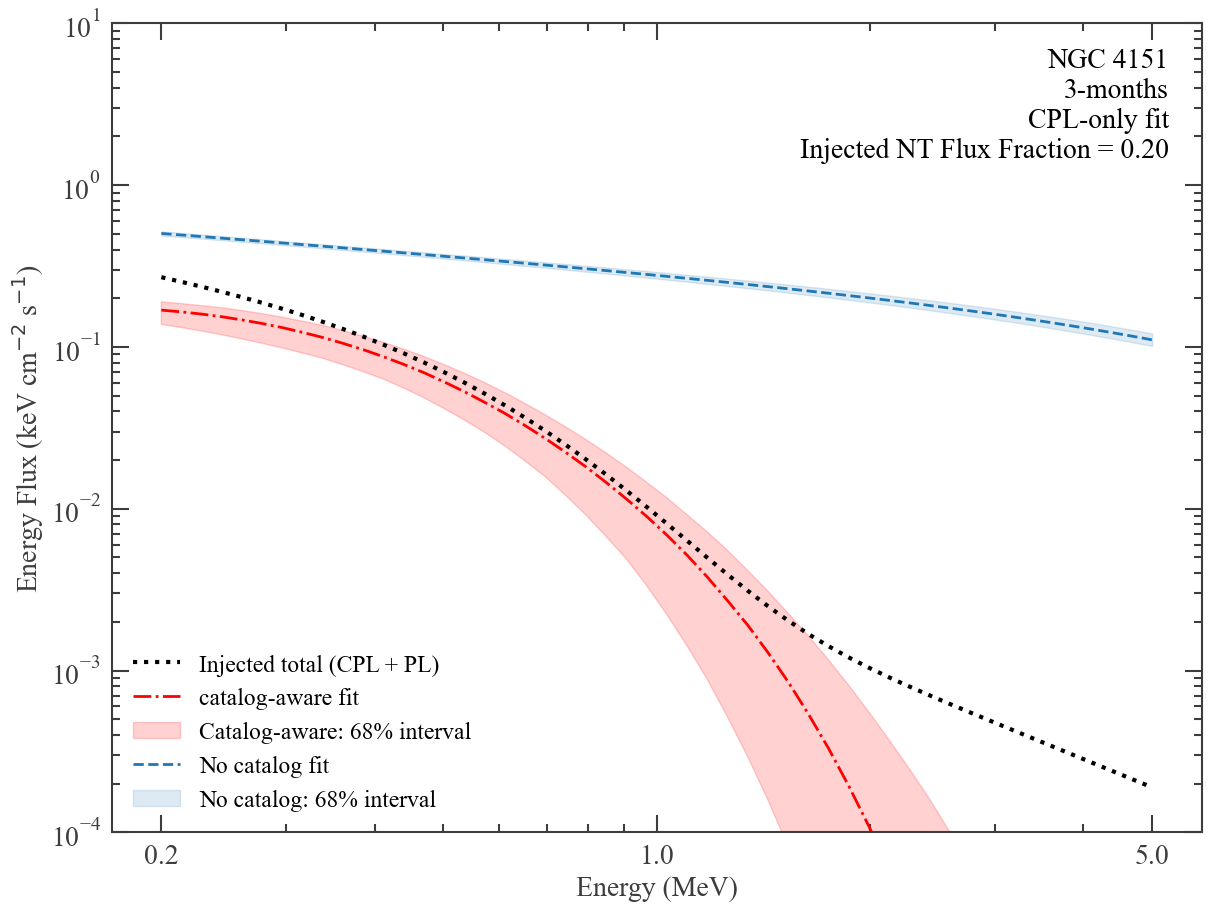

In [20]:
FONT_SIZE = 20
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected total (CPL + PL)",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label="catalog-aware fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="Catalog-aware: 68% interval",
)

ax.plot(
    energy / 1000, energy * energy * no_catalog_flux_median,
    color="tab:blue", lw=2, ls="--", label="No catalog fit",
)
ax.fill_between(
    energy / 1000, energy * energy * no_catalog_flux_lo,
    energy * energy * no_catalog_flux_hi,
    color="tab:blue", alpha=0.15, label="No catalog: 68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
# Keep the original lower limit, but do not clip a strongly biased baseline fit.
plotted_energy_flux = np.concatenate([
    energy * energy * flux_inj, energy * energy * flux_hi,
    energy * energy * no_catalog_flux_hi,
])
finite_positive_flux = plotted_energy_flux[np.isfinite(plotted_energy_flux) & (plotted_energy_flux > 0)]
ax.set_ylim(1e-4, max(10., 1.5 * finite_positive_flux.max()))
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)

thermal_flux = np.asarray([spectrum_inj_cpl.evaluate_at(e) for e in energy])
tail_flux = np.asarray([spectrum_inj_tail.evaluate_at(e) for e in energy])
thermal_energy_flux = np.trapezoid(energy * thermal_flux, energy)
tail_energy_flux = np.trapezoid(energy * tail_flux, energy)
energy_flux_ratio = tail_energy_flux / (thermal_energy_flux + tail_energy_flux)

ax.text(
    0.97,
    0.97,
    f"NGC 4151\n{exposure_months}-months\nCPL-only fit\nInjected NT Flux Fraction = {energy_flux_ratio:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="normal",
)
ax.legend(fontsize=17, loc="lower left", frameon=False)
plt.show()

Compare the complete temporally folded 71-entry catalog plus the fitted
instrumental background with the observed mock counts. This is a projection
onto measured energy; the likelihood itself fits the full Em/Phi/PsiChi space.


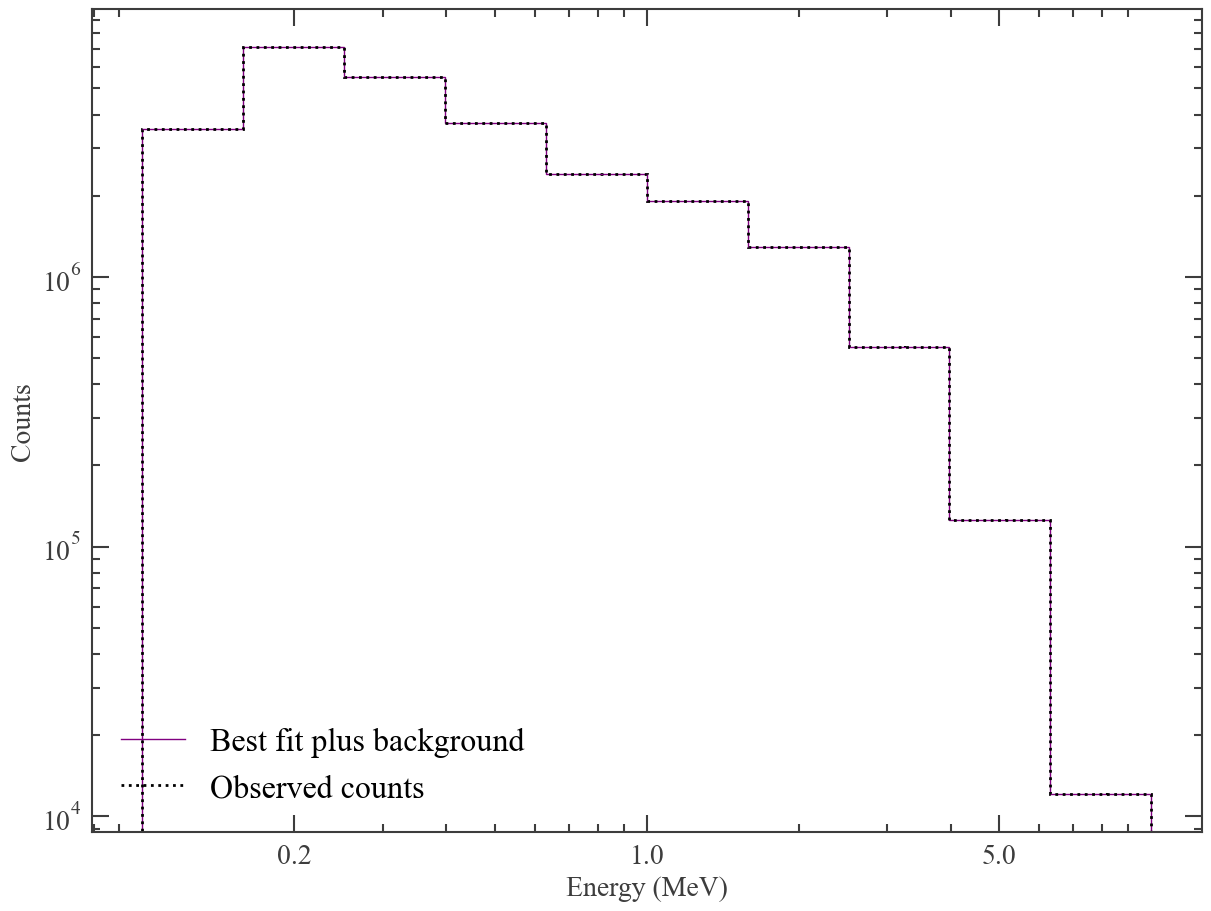

In [13]:
expectation_bkg = bkg.expectation(copy=True)
model_counts = (
    expectation.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(
    model_counts,
    binned_energy_edges / 1000,
    color="purple",
    label="Best fit plus background",
)
ax.errorbar(
    binned_energy / 1000,
    model_counts,
    yerr=np.sqrt(model_counts),
    color="purple",
    linewidth=0,
    elinewidth=1.5,
)
ax.stairs(
    data_counts,
    binned_energy_edges / 1000,
    color="black",
    ls=":",
    lw=2,
    label="Observed counts",
)
ax.errorbar(
    binned_energy / 1000,
    data_counts,
    yerr=np.sqrt(data_counts),
    color="black",
    linewidth=0,
    elinewidth=1.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()